<a href="https://colab.research.google.com/github/JaydenSanghyeopPark/JaydenSanghyeopPark/blob/main/LAB12-%EB%94%A5%EB%9F%AC%EB%8B%9D-%EC%8B%A0%EA%B2%BD%EB%A7%9D%EC%9D%98%20%EC%9D%B4%ED%95%B4_%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
!pip install hossam

# #02. AND(OR) Gate
## [1]준비작업
### 패키지 참조

In [3]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split

# 순서층을 구성하는 모델 객체 생성 가능
from tensorflow.keras.models import Sequential

# 모델 객체에 학습을 위한 층을 쌓는다.
from tensorflow.keras.layers import Dense, Input

# 옵티마이저
from tensorflow.keras.optimizers import SGD, RMSprop

# 활성화 함수
from tensorflow.keras.losses import mse

# 성능평가함수
from tensorflow.keras.metrics import RootMeanSquaredError

# 로딩바
from tqdm.keras import TqdmCallback

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.3

✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


### 데이터셋 준비

In [4]:
origin = load_data("logical_and")
# origin = load_data("logical_or")
origin

AND 논리 게이트의 입력과 출력 데이터


,x1,x2,target
0,0,0,0
1,1,0,0
2,0,1,0
3,1,1,1


## [3]데이터 전처리

In [5]:
# 전체 데이터를 학습용과 테스트용으로 모두 사용
x_train = origin.drop('target', axis=1)
y_train = origin['target']
x_test = x_train.copy()
y_test = y_train.copy()

In [7]:
rows, cols = x_train.shape
print(rows, cols)

4 2


## [4]신경망 모델 적합
### 신경망 모델 구축

In [8]:
# Sequential API를 사용하여 순차적으로 층을 쌓는 모델 객체 생성
model = Sequential()

# 입력층 정의: 각 샘플은 (cols,) 형태의 1차원 벡터임
# 예) cols=5이면 입력 데이터는 (None, 5)구조가 됨 (None은 배치 크기)
model.add(Input(shape=(cols,)))

# Dense(완전연결층) 추가
# 출력 뉴런 1개 -> 이진 분류 문제이므로 출력층 뉴런 수는 1개
model.add(Dense(1, activation="linear"))

# 모델 학습 설정 (컴파일 단계)
model.compile(
    optimizer="SGD",
    loss="mse",
    metrics=["accuracy", "mae", RootMeanSquaredError(name="rmse")],
)

# 모델 구조(층 구성, 파라미터 개수 등) 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

### 학습하기

In [9]:
%%time
result = model.fit(
    x_train,
    y_train,
    epochs=500,
    validation_split=0.2,
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

CPU times: user 37.9 s, sys: 9.98 s, total: 47.8 s
Wall time: 57.8 s


## [5]성능평가
### (1)가중치, 편향 확인

In [10]:
weight, bias = model.get_weights()
print("가중치: %s" %weight)
print("편향: %s" %bias)

가중치: [[-0.04346593]
 [-0.02851806]]
편향: [0.02634769]


## (2)성능평가 지표

In [11]:
# Train 성능 평가
# -> metrics=["accuracy", "mae", RootMeanSquaredError(name="rmse")]에의해
# evaluate()가 반환하는 리스트의 순서는 [loss, accuracy, mae, rmse]임
train_eval = model.evaluate(x_train, y_train, verbose=0, return_dict=True)
test_eval = model.evaluate(x_test, y_test, verbose=0, return_dict=True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, "Dataset", ["Train", "Test"])

# RMSE Gap 추가
final_results["rmse_gap"] = None
final_results.loc[1, "rmse_gap"] = final_results.loc[1, "rmse"] - final_results.loc[0, "rmse"]
final_results

,Dataset,accuracy,loss,mae,rmse,rmse_gap
0,Train,0.750,0.274,0.273,0.523,None
1,Test,0.750,0.274,0.273,0.523,0.000


## (3)학습 과정 확인

In [12]:
history_df = DataFrame(data=result.history)
history_df["epoch"] = history_df.index + 1

history_df.head()

,accuracy,loss,mae,rmse,val_accuracy,val_loss,val_mae,val_rmse,epoch
0,1.000,0.038,0.141,0.196,0.000,1.489,1.220,1.220,1
1,1.000,0.037,0.141,0.194,0.000,1.482,1.217,1.217,2
2,1.000,0.037,0.140,0.192,0.000,1.475,1.214,1.214,3
3,1.000,0.036,0.140,0.190,0.000,1.468,1.212,1.212,4
4,1.000,0.035,0.139,0.188,0.000,1.462,1.209,1.209,5


## (4)RMSE 학습 곡선

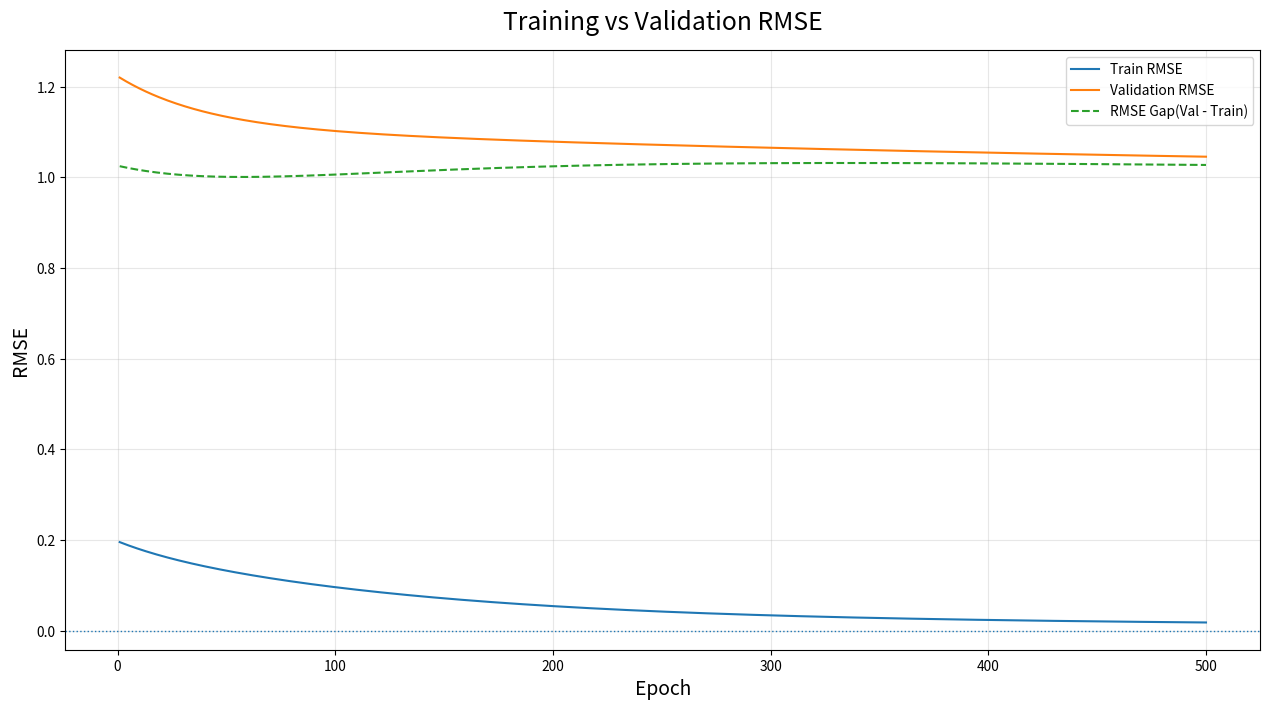

In [13]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

# Train RMSE
sb.lineplot(
    data=history_df,
    x="epoch",
    y="rmse",
    ax=ax,
    label="Train RMSE",
)

# Validation RMSE
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_rmse",
    ax=ax,
    label="Validation RMSE",
)

# RMSE Gap (보조선)
history_df["rmse_gap"] = history_df["val_rmse"] - history_df["rmse"]
sb.lineplot(
    data=history_df,
    x="epoch",
    y="rmse_gap",
    ax=ax,
    label="RMSE Gap(Val - Train)",
    linestyle="--"
)

# 기준선 (Gap = 0)
ax.axhline(0, linestyle=":", linewidth=1)

ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("Training vs Validation RMSE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## (5) MAE 시각화

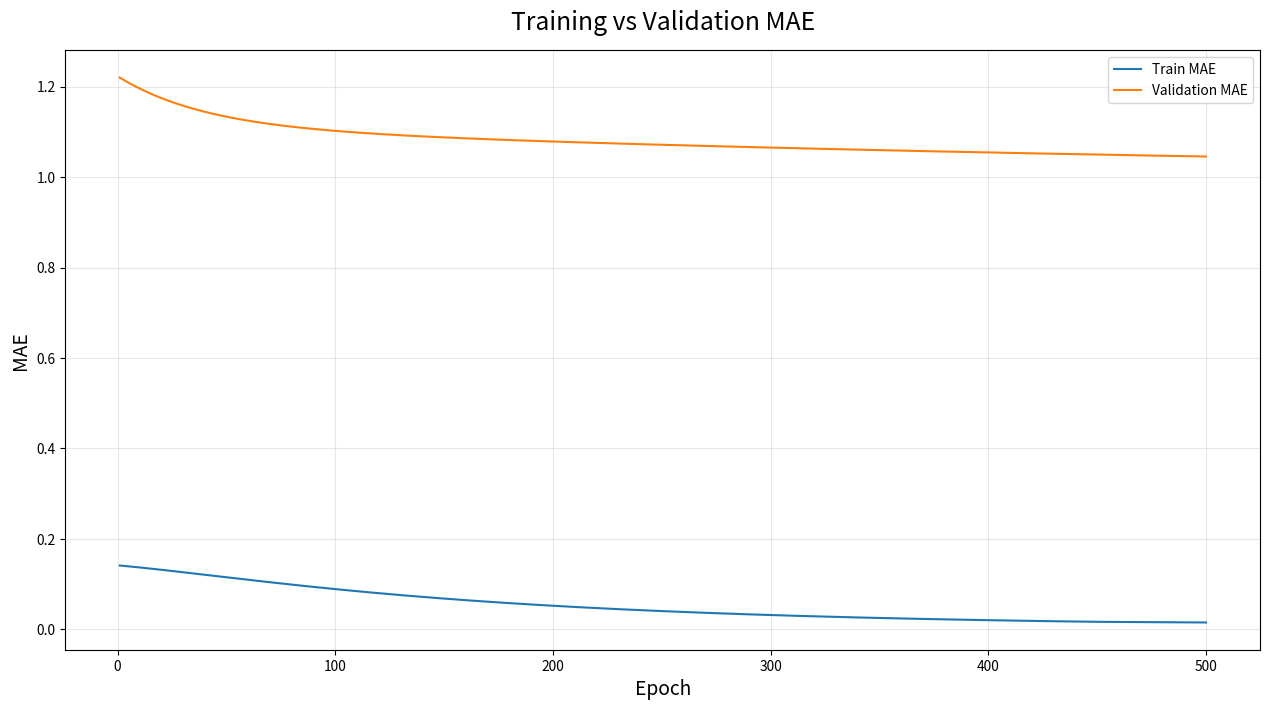

In [14]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

# Train MAE
sb.lineplot(
    data=history_df,
    x="epoch",
    y="mae",
    ax=ax,
    label="Train MAE",
)

# Validation MAE
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_mae",
    ax=ax,
    label="Validation MAE",
)


ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.set_title("Training vs Validation MAE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## (6) Loss(MSE) 학습곡선

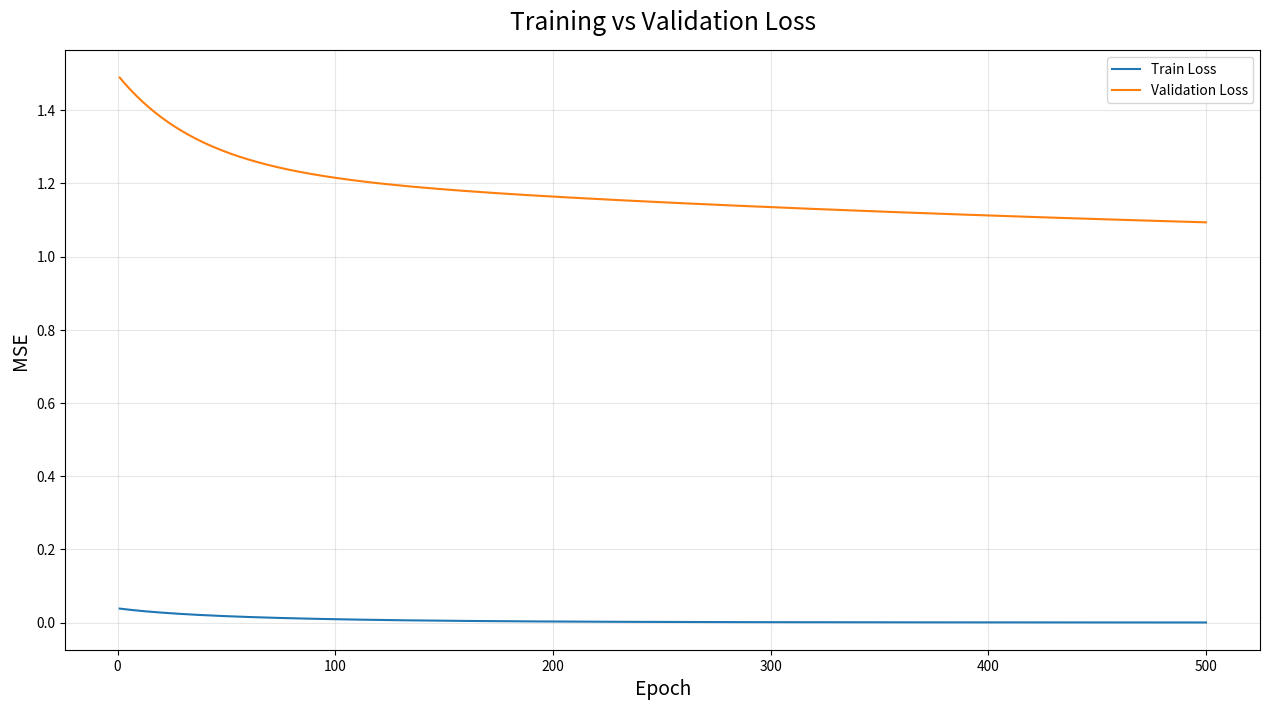

In [15]:
figsize = (1280 / 100, 720 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.lineplot(
    data=history_df,
    x="epoch",
    y="loss",
    ax=ax,
    label="Train Loss",
)

sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_loss",
    ax=ax,
    label="Validation Loss",
)


ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Training vs Validation Loss")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## (6)학습 결과 적용
### (1)단일 데이터에 대한 예측치 산정

In [18]:
for i in range(0,2):
  for j in range(0,2):
    r = model.predict(np.array([[i,j]]), verbose=0)
    print("입력: %d, %d => 출력: %0.2f" % (i, j, r[0][0]))
    print("%s, %s => %s" %(bool(j), bool(j), bool(round(r[0, 0]))))

입력: 0, 0 => 출력: 0.03
False, False => False
입력: 0, 1 => 출력: -0.00
True, True => False
입력: 1, 0 => 출력: -0.02
False, False => False
입력: 1, 1 => 출력: -0.05
True, True => False


## (2)검증 데이터 전체를 활용하여 예측값 만들기

In [19]:
r = model.predict(x_test, verbose=0)
r

array([[ 0.02634769],
       [-0.01711824],
       [-0.00217037],
       [-0.0456363 ]], dtype=float32)

In [20]:
origin["pred"] = r.reshape(-1).round()
origin

,x1,x2,target,pred
0,0,0,0,0.000
1,1,0,0,-0.000
2,0,1,0,-0.000
3,1,1,1,-0.000
